# Data Distribution Analysis Guide


## Overview
In this notebook, we will explore how to analyze data distributions by following a structured approach. 

The guide will cover understanding the data type, identifying the analytical question, calculating descriptive statistics, interpreting graphs and statistics.

The notebook has a toggle markdown cell `"Compare Answer"`
You can click to toggle to validate if your answer is close. It does not have to be exact. 

Recommended to use the markdown files in the repo as they have summarised steps overview with the relevant calculations.




1. Understand the Data Type: Continuous or discrete.

2. Identify the Analytical Question: Determine which distribution fits your question.

3. Calculate Descriptive Statistics: Compute and visualize summary statistics.

4. Interpret the Graph and Descriptive Statistics: Analyze the data’s distribution and patterns.



---



# Case Study- Time Between Customer Purchases:
You will be guided step-by-step:



Scenario: An e-commerce company wants to analyze the time between customer purchases to improve marketing strategies.

They are not sure what kind of distribution to use yet.



---

## 1. Understand the Data Type

### Step: Determine Whether Your Data is Continuous or Discrete

- **Continuous Data**: Takes on any value within a range. Examples include height, temperature, or time. Common distributions for continuous data include:
  - **Normal Distribution**: Used for data that is symmetrically distributed around the mean.
  - **Exponential Distribution**: Used for modeling the time between events.
  - **Log-Normal Distribution**: Used for data that is normally distributed when logged.

- **Why It Matters**: The type of data determines which probability distribution and statistical methods are appropriate for analysis.



### Question: What type of data are we working with in the case study?



Hint: Some distributions are used for counts (like the number of complaints per day), and others are used for time or measurements (like waiting time, height, or revenue).

#### Your answer here:


<details>
  <summary>Compare Answer</summary>
  <h3>Answer:</h3>
  <p>The data is continuous because it represents the time between customer purchases, which can take any positive value.</p>
  
</details>

---


## 2. Identify the Analytical Question

### Now that you know the data type, the next step is to ask: 
`What exactly do we want to find out from this data?`


Here’s a simple decision guide:

- Counting successes in a fixed number of attempts?
  - → Use Binomial (e.g., number of defective items in a batch of 20).

- Counting events over time or space?
  - → Use Poisson (e.g., number of complaints per day).

- Looking at the time between events?
  - → Use Exponential (e.g., time between two customers arriving).

- Measuring continuous things like height, weight, revenue?
  - → Use Normal (bell curve).

**Why It Matters**: Once you know the type of question, you can match it to the right distribution. This makes it easier to describe the data and check if your assumption about the pattern is reasonable.



### Question: What is the main question or goal for this analysis?

Hint:

If we were counting the number of purchases in a day, we might use Poisson.

But here, we’re measuring time between events. Which distribution usually models that?

#### Your Answer here:


<details>
  <summary>Compare Answer</summary>
  <h3>Answer:</h3>
  <p>The goal is to determine whether the time between customer purchases follows an Exponential distribution and to visualize this distribution.</p>
  
</details>

---

## 3. Calculate Descriptive Statistics

### Step: Compute Summary Statistics to Describe the Data

- **Descriptive Statistics**:
  - **For Continuous Data**: Mean, median, variance, standard deviation, skewness, and kurtosis.

- **Visualizations**:
  - **Histograms**: To visualize the distribution of data.
  - **Bar Charts**: For discrete data counts.
  - **Box Plots**: To assess the spread and central tendency.

- **Why It Matters**: Descriptive statistics provide a summary of the data’s main features, which helps in understanding its distribution and characteristics.



### Question: What descriptive statistics should we calculate for this data?


**Did you know?**
For an Exponential distribution, the mean and the standard deviation are usually about the same.

This property gives us a quick way to check if the data might actually follow an Exponential pattern.

#### Your Answer here:


<details>
  <summary>Compare Answer</summary>
  <h3>Answer:</h3>
  <p>Calculate the mean and standard deviation of the time between purchases. For an Exponential distribution,
  
   the mean ~= `1/𝜆`

​and the standard deviation ~= `1/𝜆`

where `𝜆` = rate parameter.</p>
  
</details>

---

## 4. Interpret the Graph and Descriptive Statistics

### Step: Analyze the Graphical Representation and Descriptive Statistics

- **Graphs**:
  - Examine the shape, center, and spread of the data.
  - Identify patterns, outliers, and whether the data fits the expected distribution shape.

- **Descriptive Statistics**:
  - Assess the mean, median, variance, and other statistics to understand the data’s distribution and central tendencies.

- **Why It Matters**: Interpretation helps in understanding how well the data fits the assumed distribution and in identifying any anomalies or patterns.

[Scipy stats docs](https://docs.scipy.org/doc/scipy/reference/stats.html)

### Question: How can we interpret the histogram and the descriptive statistics?

In [1]:
# We will import the necessary package

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import expon, norm  # our stats package that contains the functions, here we import expon specifically

In [2]:
# Read the data
df_purchase = pd.read_csv("data/time_between_purchase.csv")

In [3]:
df_purchase.head()

,purchase
0,8.002824
1,12.315078
2,3.437654
3,7.150403
4,22.344308


In [4]:
# Next we must calculate the descriptive stats. We will utilize np again for this, its just convenient. If the data was stored in a DF you can use
# pandas methods

# Descriptive statistics
mean_time = df_purchase["purchase"].mean()
std_dev_time =  df_purchase["purchase"].std()

In [5]:
# check the output
print(f" the mean number of time are {mean_time}")
print(f" the standard deviation of time are {std_dev_time}")


 the mean number of time are 9.561474322984747
 the standard deviation of time are 9.477243010031438


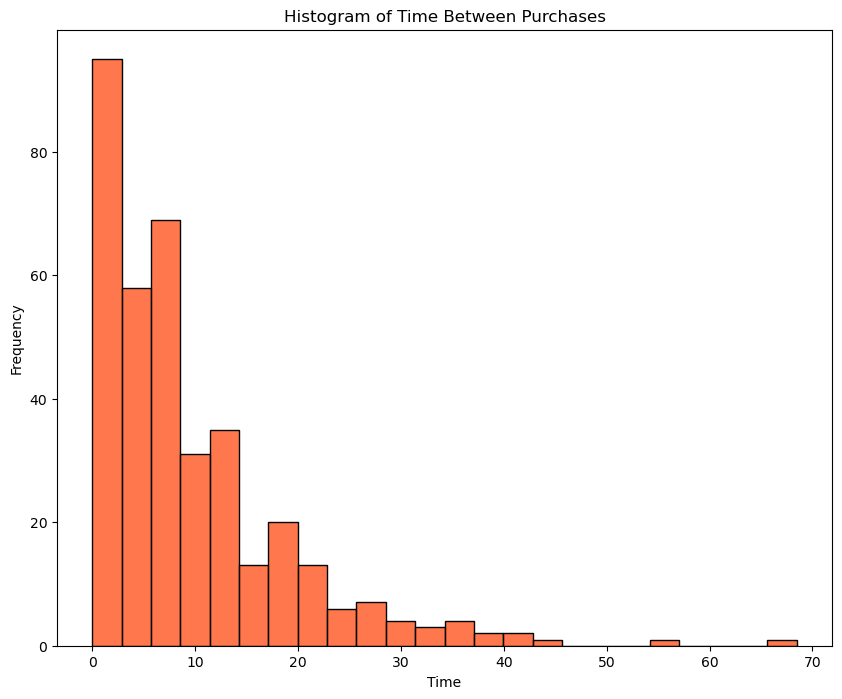

In [7]:
""" Histogram of Time Between Purchases:

Interpretation:
The histogram represents the frequency distribution of the time intervals between customer purchases.
For an exponential distribution, the histogram typically shows a rapid decline,
 with most of the data concentrated near the lower values. 
 This pattern indicates that shorter intervals between purchases are more common, and longer intervals are less frequent.
The shape of the histogram, with a high frequency of small time intervals and a long tail towards the right, 
aligns with the characteristics of an exponential distribution.

"""
plt.figure(figsize=(10,8))
sns.histplot(df_purchase["purchase"], kde=False, color='#ff4a11ff')
plt.title('Histogram of Time Between Purchases')
plt.xlabel('Time')
plt.ylabel('Frequency')
plt.show()

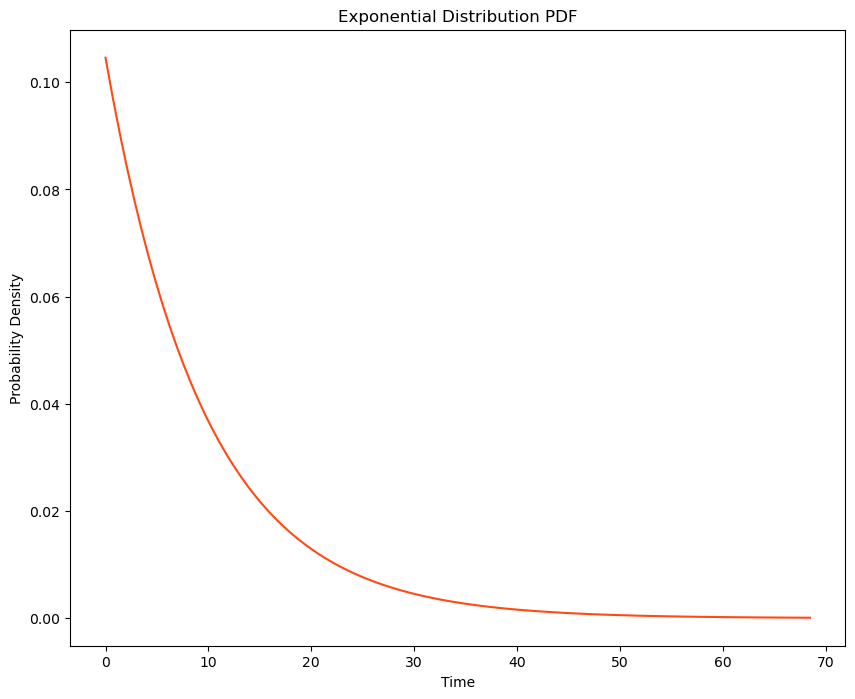

In [8]:
"""Exponential Distribution PDF (Probability Density Function) Plot:

Interpretation:
The PDF plot represents the theoretical exponential distribution curve based on the mean of the data.
The curve starts high and decays rapidly as time increases,
 indicating that the likelihood of longer intervals between purchases decreases exponentially.
The alignment between the histogram and the PDF plot suggests that the observed data follows an exponential distribution, 
with the majority of intervals being short and fewer longer intervals.
"""

# Exponential Distribution Plot
plt.figure(figsize=(10,8))
x = np.linspace(0, max(df_purchase['purchase']), 100)
pdf = expon.pdf(x, scale=mean_time)

plt.plot(x, pdf, color='#ff4a11ff')
plt.title('Exponential Distribution PDF')
plt.xlabel('Time')
plt.ylabel('Probability Density')
plt.show()

---

# CASE STUDY- Delivery Times


Scenario:

You are working as a data analyst at a logistics company.
Your manager asks you:

“Can we give customers a reliable delivery estimate, like 95% of deliveries will arrive within X days?”

To answer this, you need to check how delivery times are distributed.

Are they centered around an average (Normal distribution)? Or are they skewed (Exponential distribution)?



1. Understand the Data Type: Continuous or discrete.

2. Identify the Analytical Question: Determine which distribution fits your question.

3. Calculate Descriptive Statistics: Compute and visualize summary statistics.

4. Interpret the Graph and Descriptive Statistics: Analyze the data’s distribution and patterns.


---

## Step 1: Understand the Data Type 



### Question: What type of data are we working with?

#### Your Answer here:


<details>
  <summary>Compare Answer</summary>
  <h3>Answer:</h3>
  <p>The data is continuous because it represents delivery times, which can take any positive value.</p>
  
</details>

---

## Step 2:  Identify the Analytical Question


Manager’s Question:

- What is the typical delivery time?

- How much do delivery times vary?

- Can we set a promise like “95% of deliveries arrive within X days”?

To answer these, we need to check the shape of the data:

- If it’s symmetric and bell-shaped → likely a Normal distribution.

- If it’s skewed, with most times short and a few very long → might be Exponential or another skewed distribution.

### Question: What is the main question or goal for this analysis?

#### Your Answer here


<details>
  <summary>Compare Answer</summary>
  <h3>Answer:</h3>
  <p>The goal is to check whether delivery times follow a Normal distribution, so we can make reliable predictions and set expectations.
</p>
  
</details>

--- 

## Step 3:  Calculate Descriptive Statistics

### Question: What descriptive statistics should we calculate for this data?
hint:  Refer to step 3 in the markdown file for distribution_functions


#### Your answer here: 


<details>
  <summary>Compare Answer</summary>
  <h3>Answer:</h3>
  <p>Calculate the mean and standard deviation of the delivery times. For a Normal distribution, these values describe the center and spread of the distribution.
</p>
  
</details>

--- 

## Step 4: Interpret the Graph and Descriptive Statistics

### Question: How can we interpret the histogram and the descriptive statistics?

#### Your Answer here

<details>
  <summary>Compare Answer</summary>
  <h3>Answer:</h3>
  <p>The histogram should show the distribution of delivery times. If the data fits a Normal distribution, the mean and standard deviation should reflect the shape of the Normal curve.

</p>
  
</details>

In [9]:
df_delivery = pd.read_csv("data/delivery.csv")

df_delivery.head()

,delivery_time
0,54.412275
1,46.691298
2,74.307712
3,47.479079
4,51.096098


In [10]:
# calculate the descriptive stats
mean_time = df_delivery['delivery_time'].mean()
std_dev_time = df_delivery['delivery_time'].std()

In [11]:
# check the output
print(f" the mean: {mean_time}")
print(f" the standard_deviation: {std_dev_time}")

 the mean: 50.16432690561987
 the standard_deviation: 9.7409731599036


Text(0, 0.5, 'Frequency')

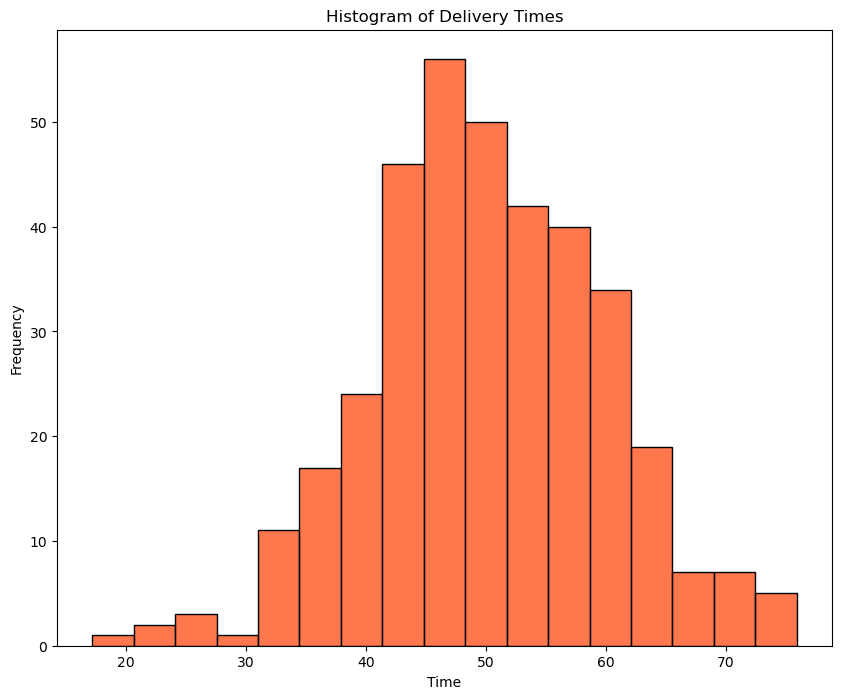

In [12]:
# Plotting
"""
Histogram of Delivery Times:

Interpretation:
The histogram represents the frequency distribution of the delivery times.
If the data is normally distributed, the histogram should have a bell-shaped curve,
 with most data points concentrated around the mean (50 units) and tapering off symmetrically towards the tails.
The histogram shows that most delivery times are clustered around 50 units, 
with fewer occurrences as you move further away from the mean.
 This bell-shaped pattern confirms that the data follows a normal distribution.



"""

# Histogram
plt.figure(figsize=(10, 8))
sns.histplot(df_delivery["delivery_time"], kde=False, color='#ff4a11ff')
plt.title('Histogram of Delivery Times')
plt.xlabel('Time')
plt.ylabel('Frequency')

Text(0, 0.5, 'Probability Density')

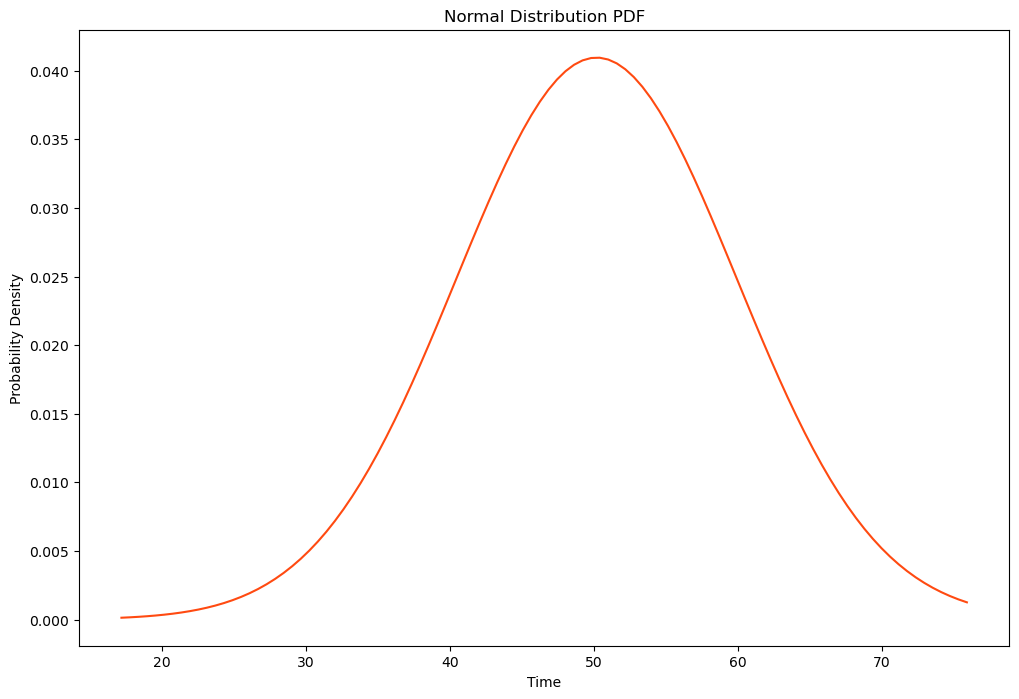

In [13]:
""" 

Normal Distribution PDF (Probability Density Function) Plot:

Interpretation:
The PDF plot represents the theoretical normal distribution curve based on the mean and standard deviation of the data.
The curve peaks at the mean (50 units) and decreases symmetrically as you move away from the mean.
The PDF plot should align well with the shape of the histogram. 
This alignment indicates that the observed delivery times follow a normal distribution.
The area under the curve represents the probability of different delivery times occurring.
"""


# Normal Distribution Plot
x = np.linspace(min(df_delivery['delivery_time']), max(df_delivery['delivery_time']), 100)
pdf = norm.pdf(x, mean_time, std_dev_time)
plt.figure(figsize=(12,8))
plt.plot(x, pdf, color='#ff4a11ff')
plt.title('Normal Distribution PDF')
plt.xlabel('Time')
plt.ylabel('Probability Density')